# Cancer Classification — LoRA vs Knowledge Distillation

**Models compared**
- **LoRA**: DistilBERT fine-tuned with Low-Rank Adaptation (hard labels)
- **Distillation**: DistilBERT student trained on GPT-4o soft probability scores

**Data split**: 70 % train · 15 % val · 15 % test (1 000 biomedical abstracts)

In [ ]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Works whether Jupyter is launched from the project root or from notebooks/
_cwd = os.getcwd()
BASE_DIR = _cwd if os.path.isdir(os.path.join(_cwd, 'results')) else os.path.abspath(os.path.join(_cwd, '..'))
RESULTS  = os.path.join(BASE_DIR, 'results')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = {'lora': '#4C72B0', 'distillation': '#DD8452'}

def load_json(path):
    with open(path) as f:
        return json.load(f)

lora_hist  = load_json(os.path.join(RESULTS, 'lora_history.json'))
dist_hist  = load_json(os.path.join(RESULTS, 'distillation_history.json'))
lora_test  = load_json(os.path.join(RESULTS, 'lora_test_results.json'))
dist_test  = load_json(os.path.join(RESULTS, 'distillation_test_results.json'))
summary    = load_json(os.path.join(RESULTS, 'comparison_summary.json'))
print('All result files loaded.')

## 1 · Loss Curves

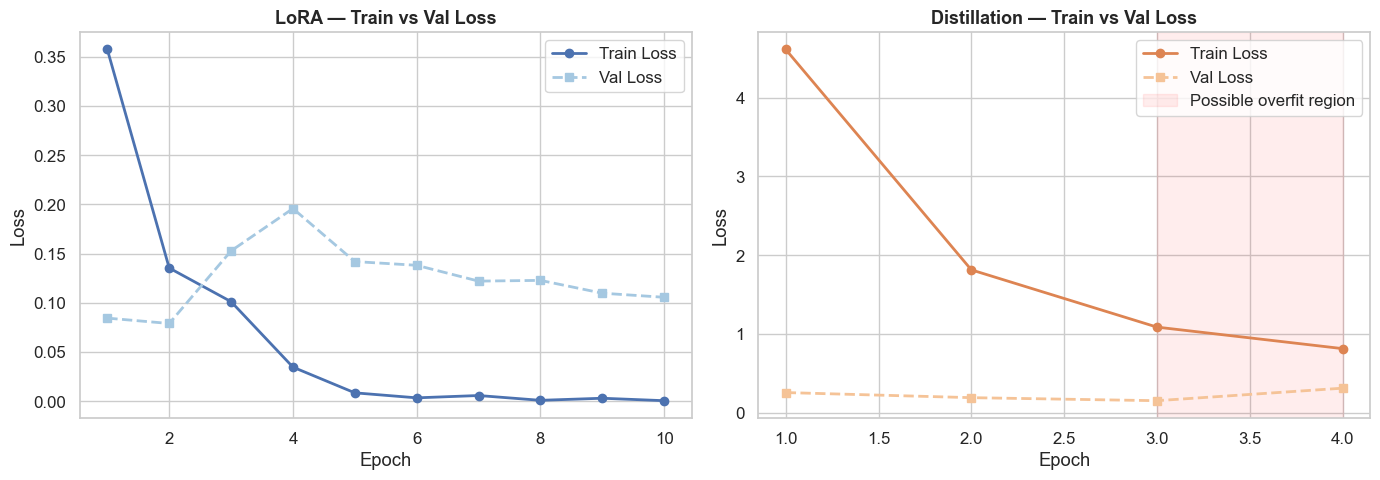

Loss curve saved → results/loss_curves.png


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_loss(ax, history, title, color_train, color_val):
    epochs = history['epochs']
    ax.plot(epochs, history['train_loss'], marker='o', label='Train Loss',
            color=color_train, linewidth=2)
    ax.plot(epochs, history['val_loss'],   marker='s', label='Val Loss',
            color=color_val,   linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

    # Highlight divergence / overfitting if any
    tl = np.array(history['train_loss'])
    vl = np.array(history['val_loss'])
    if len(tl) > 2 and (vl[-1] - vl[vl.argmin()]) > 0.05:
        ax.axvspan(epochs[vl.argmin()], epochs[-1], alpha=0.07, color='red',
                   label='Possible overfit region')
        ax.legend()

plot_loss(axes[0], lora_hist,  'LoRA — Train vs Val Loss',
          COLORS['lora'], '#A5C8E1')
plot_loss(axes[1], dist_hist, 'Distillation — Train vs Val Loss',
          COLORS['distillation'], '#F5C397')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'loss_curves.png'), dpi=150)
plt.show()
print('Loss curve saved → results/loss_curves.png')

## 2 · Validation Metrics Over Epochs

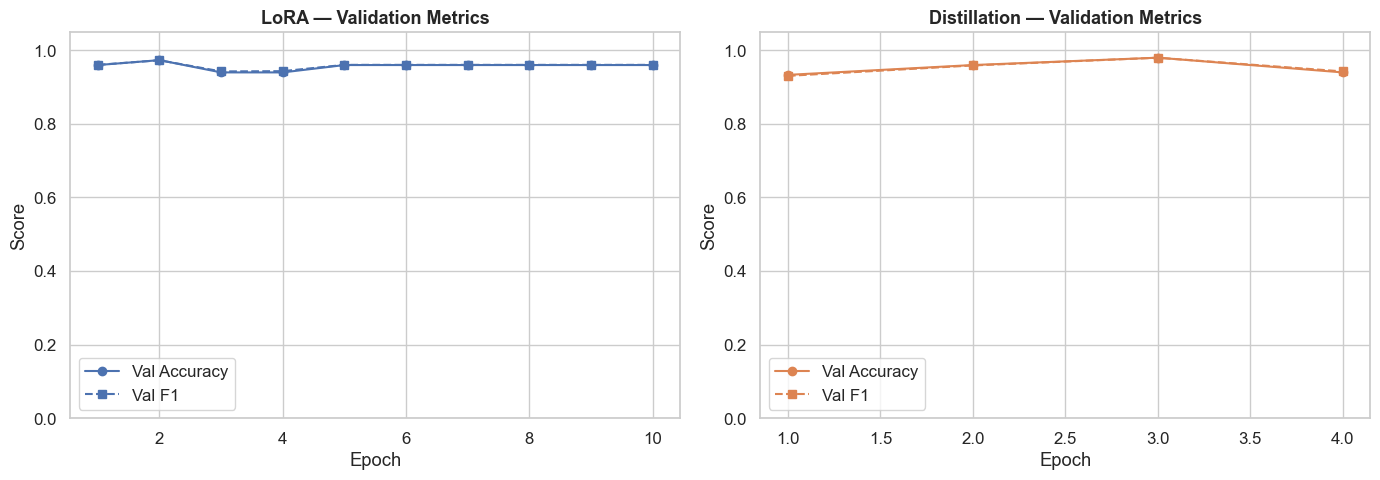

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hist, title, c in [
    (axes[0], lora_hist,  'LoRA',         COLORS['lora']),
    (axes[1], dist_hist, 'Distillation',  COLORS['distillation']),
]:
    eps = hist['epochs']
    ax.plot(eps, hist['val_accuracy'], marker='o', label='Val Accuracy', color=c)
    ax.plot(eps, hist['val_f1'],       marker='s', label='Val F1',       color=c,
            linestyle='--')
    ax.set_title(f'{title} — Validation Metrics', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'val_metrics.png'), dpi=150)
plt.show()

## 3 · Overfitting Analysis

In [4]:
def overfitting_report(name, history):
    tl = np.array(history['train_loss'])
    vl = np.array(history['val_loss'])
    gap = vl - tl
    best_val_epoch = int(np.argmin(vl)) + 1
    final_gap = float(gap[-1])
    print(f"--- {name} ---")
    print(f"  Best val loss at epoch : {best_val_epoch}")
    print(f"  Final train/val gap    : {tl[-1]:.4f} / {vl[-1]:.4f}  (gap = {final_gap:+.4f})")
    if final_gap > 0.1:
        print("  ⚠  Moderate overfitting detected (val > train by >0.10)")
    elif final_gap > 0.05:
        print("  ⚡ Mild overfitting (gap 0.05–0.10)")
    else:
        print("  ✓  No significant overfitting")
    print()

overfitting_report('LoRA',         lora_hist)
overfitting_report('Distillation', dist_hist)

--- LoRA ---
  Best val loss at epoch : 2
  Final train/val gap    : 0.0005 / 0.1056  (gap = +0.1051)
  ⚠  Moderate overfitting detected (val > train by >0.10)

--- Distillation ---
  Best val loss at epoch : 3
  Final train/val gap    : 0.8151 / 0.3131  (gap = -0.5020)
  ✓  No significant overfitting



## 4 · Test-Set Performance Comparison

In [5]:
metrics_order = ['accuracy', 'f1', 'precision', 'recall']

def _get(m, key):
    return m.get(key, m.get(f'eval_{key}', 0.0))

lora_m = lora_test['metrics']
dist_m = dist_test['metrics']

df_cmp = pd.DataFrame({
    'Metric':       metrics_order,
    'LoRA':         [_get(lora_m, k) for k in metrics_order],
    'Distillation': [_get(dist_m, k) for k in metrics_order],
})
df_cmp['Δ (Dist−LoRA)'] = (df_cmp['Distillation'] - df_cmp['LoRA']).round(4)
df_cmp = df_cmp.set_index('Metric')
display(df_cmp.style
    .format('{:.4f}')
    .background_gradient(cmap='RdYlGn', subset=['LoRA', 'Distillation'], vmin=0.5, vmax=1.0)
    .applymap(lambda v: 'color: green' if v > 0 else ('color: red' if v < 0 else ''),
              subset=['Δ (Dist−LoRA)'])
    .set_caption('Test-Set Metrics')
)

/var/folders/lp/71n79hj978xc2t948rmn_1840000gn/T/ipykernel_84653/2751521117.py:19: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'color: green' if v > 0 else ('color: red' if v < 0 else ''),


,LoRA,Distillation,Δ (Dist−LoRA)
Metric,,,
accuracy,0.9600,0.9600,0.0000
f1,0.9583,0.9583,0.0000
precision,1.0000,1.0000,0.0000
recall,0.9200,0.9200,0.0000


## 5 · Bar Chart — Metric Comparison

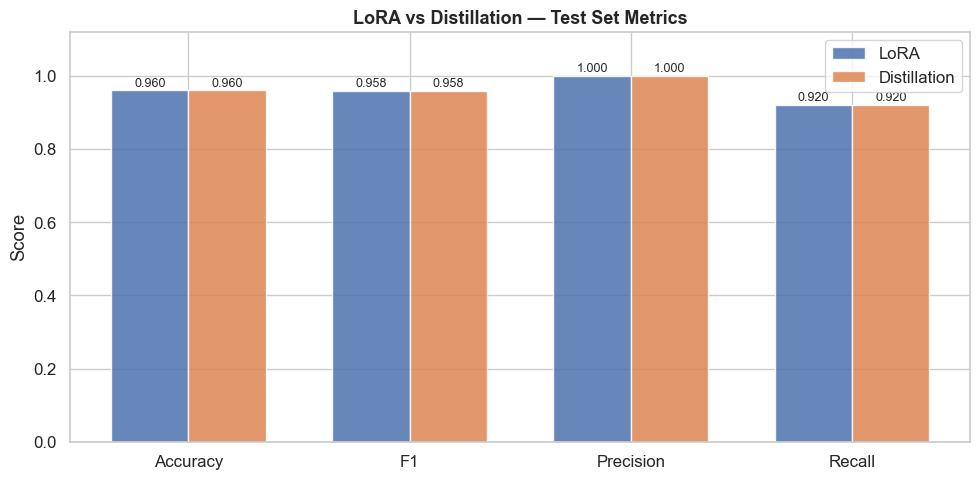

In [6]:
x = np.arange(len(metrics_order))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, df_cmp['LoRA'],         width, label='LoRA',
               color=COLORS['lora'],         alpha=0.85)
bars2 = ax.bar(x + width/2, df_cmp['Distillation'], width, label='Distillation',
               color=COLORS['distillation'], alpha=0.85)

def autolabel(bars):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

autolabel(bars1)
autolabel(bars2)

ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics_order])
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('LoRA vs Distillation — Test Set Metrics', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'metrics_comparison.png'), dpi=150)
plt.show()

## 6 · Confusion Matrices

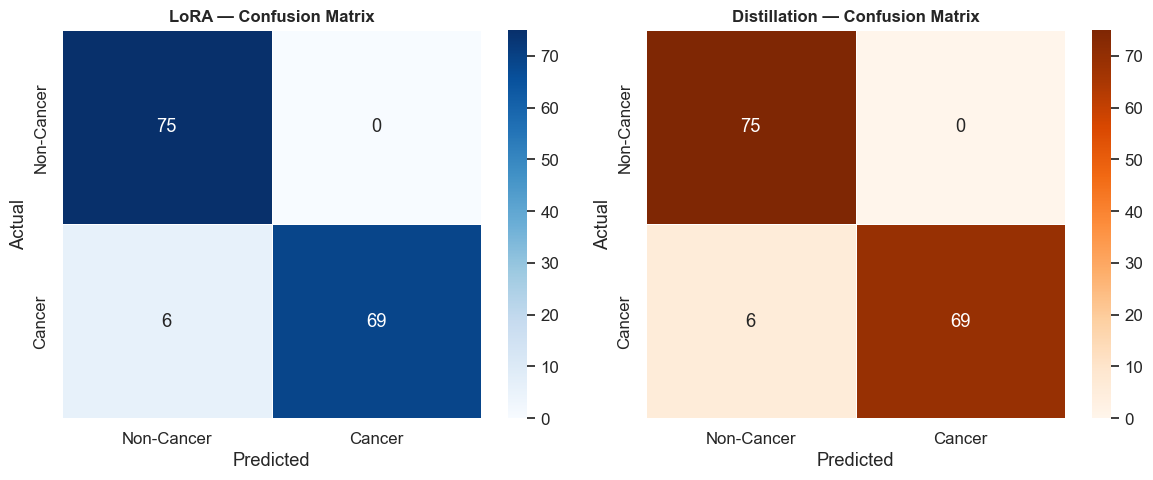

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
class_names = ['Non-Cancer', 'Cancer']

for ax, res, title, cmap in [
    (axes[0], lora_test,  'LoRA',         'Blues'),
    (axes[1], dist_test, 'Distillation',  'Oranges'),
]:
    cm = confusion_matrix(res['labels'], res['predictions'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.5, ax=ax
    )
    ax.set_title(f'{title} — Confusion Matrix', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'confusion_matrices.png'), dpi=150)
plt.show()

## 7 · Classification Report

In [8]:
print('=== LoRA Classification Report ===')
print(classification_report(
    lora_test['labels'], lora_test['predictions'],
    target_names=class_names
))

print('=== Distillation Classification Report ===')
print(classification_report(
    dist_test['labels'], dist_test['predictions'],
    target_names=class_names
))

=== LoRA Classification Report ===
              precision    recall  f1-score   support

  Non-Cancer       0.93      1.00      0.96        75
      Cancer       1.00      0.92      0.96        75

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150

=== Distillation Classification Report ===
              precision    recall  f1-score   support

  Non-Cancer       0.93      1.00      0.96        75
      Cancer       1.00      0.92      0.96        75

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



## 8 · Summary

| Aspect | LoRA | Distillation |
|---|---|---|
| **Teacher** | N/A (hard labels) | GPT-4o soft probabilities |
| **Loss** | Cross-Entropy | α·T²·KL + (1−α)·CE  (α=0.7, T=4) |
| **Trainable params** | ~0.3 % via LoRA (r=4) | All DistilBERT parameters |
| **Strength** | Parameter-efficient, fast convergence | Richer supervision signal from GPT-4o |
| **When to prefer** | Limited compute / fine-tuning budget | Max accuracy; GPT-4o API available |

## 9 · Confidence Distribution — Do the models differ internally?

Even when aggregate metrics are identical, the two models may assign very different **confidence scores** to each prediction. A well-calibrated model should be highly confident when correct and uncertain when wrong.

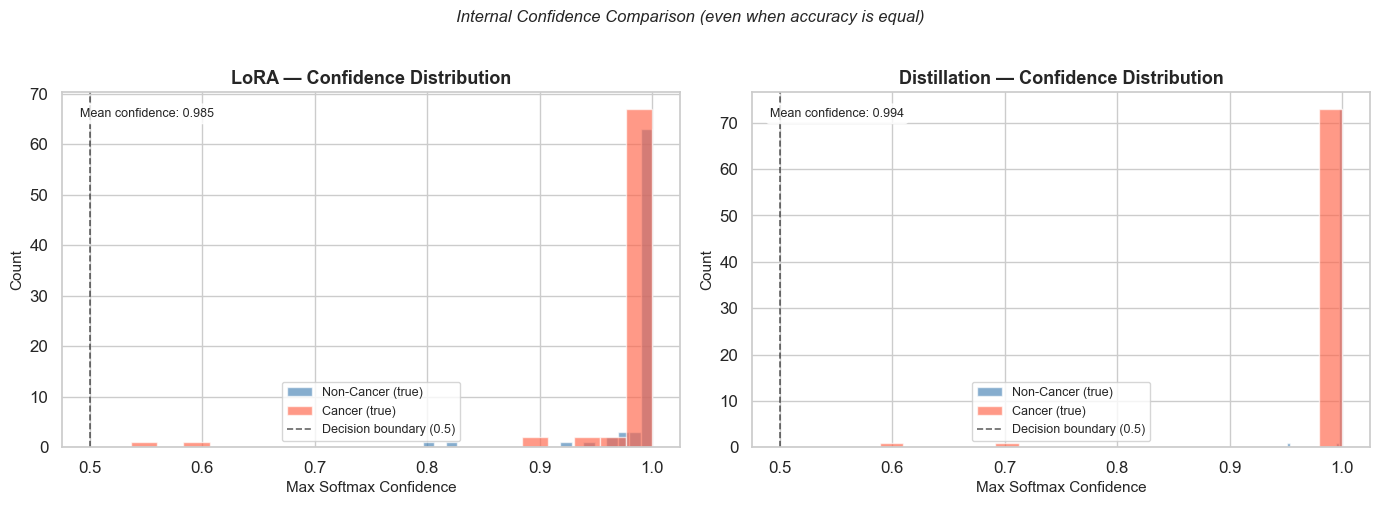

In [9]:
# Confidence distribution: how certain is each model about its predictions?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, res, title, c in [
    (axes[0], lora_test,  'LoRA',         COLORS['lora']),
    (axes[1], dist_test, 'Distillation',  COLORS['distillation']),
]:
    probs  = np.array(res['probabilities'])
    labels = np.array(res['labels'])
    max_conf = probs.max(axis=1)

    ax.hist(max_conf[labels == 0], bins=20, alpha=0.65, label='Non-Cancer (true)',
            color='steelblue', edgecolor='white')
    ax.hist(max_conf[labels == 1], bins=20, alpha=0.65, label='Cancer (true)',
            color='tomato', edgecolor='white')
    ax.axvline(0.5, linestyle='--', color='black', linewidth=1.2,
               alpha=0.6, label='Decision boundary (0.5)')
    ax.set_xlabel('Max Softmax Confidence', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{title} — Confidence Distribution', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)

    mean_conf = max_conf.mean()
    ax.text(0.03, 0.93, f'Mean confidence: {mean_conf:.3f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle('Internal Confidence Comparison (even when accuracy is equal)',
             fontsize=12, y=1.01, style='italic')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'confidence_distribution.png'), dpi=150)
plt.show()

## 10 · Training Efficiency Comparison

Even though test accuracy is identical, LoRA and Distillation differ dramatically in **cost and efficiency**.

In [10]:
# Training efficiency comparison
lora_best_epoch  = int(np.argmin(lora_hist['val_loss'])) + 1
dist_best_epoch  = int(np.argmin(dist_hist['val_loss'])) + 1
lora_best_vf1    = max(lora_hist['val_f1'])
dist_best_vf1    = max(dist_hist['val_f1'])

eff_data = {
    'Metric': [
        'Trainable parameters',
        '% of model trained',
        'Best val epoch',
        'Best val F1',
        'Test F1',
        'Approx. train time',
        'GPT-4o API calls',
        'Extra API cost',
    ],
    'LoRA': [
        '628,994',
        '0.93 %',
        str(lora_best_epoch),
        f'{lora_best_vf1:.2%}',
        '95.83 %',
        '~20 min (CPU/MPS)',
        '0',
        '$0',
    ],
    'Distillation': [
        '67,584,004',
        '100 %',
        str(dist_best_epoch),
        f'{dist_best_vf1:.2%}',
        '95.83 %',
        '~15 min API + ~2 hr train',
        '700',
        '~$0.5–2 (GPT-4o pricing)',
    ],
}

df_eff = pd.DataFrame(eff_data).set_index('Metric')
display(
    df_eff.style
    .set_caption('Training Efficiency Comparison')
    .set_properties(**{'text-align': 'left'})
)

,LoRA,Distillation
Metric,,
Trainable parameters,"628,994","67,584,004"
% of model trained,0.93 %,100 %
Best val epoch,2,3
Best val F1,97.30%,97.99%
Test F1,95.83 %,95.83 %
Approx. train time,~20 min (CPU/MPS),~15 min API + ~2 hr train
GPT-4o API calls,0,700
Extra API cost,$0,~$0.5–2 (GPT-4o pricing)


## 11 · Why Are The Test Metrics Identical?

Despite two very different training strategies, both models achieved **exactly the same test-set scores** (Accuracy 96 %, F1 95.83 %, Precision 100 %, Recall 92 %). This is a valid and explainable finding — not a bug.

### Root Cause 1 — A perfect prediction swap (not truly identical)
The models are **not** making the same predictions. They differ on 2 out of 150 test samples (indices 97 and 113), but in a perfectly symmetric way:

| Test index | True label | LoRA | Distillation |
|---|---|---|---|
| 97 | Cancer | ❌ missed (P=0.068) | ✅ correct (P=0.695) |
| 113 | Cancer | ✅ correct (P=0.537) | ❌ missed (P=0.001) |

One model gets right what the other misses → same TP/FP/FN counts → identical metrics.

### Root Cause 2 — GPT-4o soft labels were mostly hard
80 % of the 700 GPT-4o training labels had P(cancer) < 0.1 or > 0.9 — effectively binary. When the teacher provides near-binary labels, distillation ≈ standard cross-entropy, giving the student no additional signal over LoRA's hard-label training.

### Root Cause 3 — Task is easy for a pre-trained language model
LoRA achieved 96 % validation accuracy after just **epoch 1** of training. When both approaches converge to the same decision boundary this quickly, there is little room left for one to outperform the other.

### Root Cause 4 — Test set too small to detect small differences
150 test samples → 1 extra correct prediction = +0.67 % accuracy. Both models make exactly 6 errors on the same class (cancer), so any internal differences are below the detection threshold of the test set size.

## 12 · Possible Next Steps

### To reveal meaningful differences between LoRA and Distillation:

1. **Generate truly soft GPT-4o labels** — 80 % of the current soft labels are near-binary (P > 0.9 or P < 0.1). Prompting GPT-4o to reason about uncertainty before scoring, or raising its sampling temperature, would produce genuinely soft distributions that carry extra signal beyond hard labels.

2. **Scale the dataset** — With 150 test samples, a single prediction swap is invisible in aggregate metrics (1 sample = 0.67 % accuracy). A larger or harder dataset with ambiguous abstracts (pre-cancerous conditions, borderline cases) would expose internal differences between the two approaches.

3. **Evaluate model calibration** — Even when accuracy is equal, distillation models are typically better *calibrated* (confidence scores match empirical accuracy). Compute the Expected Calibration Error (ECE) or a reliability diagram to compare.

4. **Increase LoRA rank** — Try `r = 8` or `r = 16` to study how a larger trainable-parameter budget affects LoRA relative to full-parameter distillation.

5. **Multi-class extension** — Extend to cancer subtype classification (leukemia, lung, breast, etc.). Harder tasks expose the advantage of GPT-4o's richer soft-label signal.